

# Project : FleetFulcrum – Fleet Efficiency & Sustainability Analytics

Fuel efficiency, idling waste, CO2 emissions and electric vehicle replacement savings for a vehicle fleet.

## What this notebook does
- Makes 12 months of made-up data for a mixed fleet (or uses your fleet.csv if uploaded)
- Calculates cost per km, CO2 per km and idling waste for each vehicle
- Finds vehicles that cost much more than others of the same type
- Compares Linear Regression and Random Forest for diesel fuel use (5-fold cross-validation by vehicle) and ranks the drivers with the simpler model
- Estimates savings from replacing old diesel vehicles with electric ones, with a price sensitivity table
- Uses Groq AI to write fleet manager recommendations

## How to run
1. Upload this file to Google Colab (or open it from Drive)
2. Runtime → Run all, or run each cell one by one
3. If a step fails, run the cell again, then restart the runtime once and run again

## Step 1: Install libraries

In [1]:
!pip install -q pandas numpy matplotlib seaborn scikit-learn openai

## Step 2: Connect to Groq (the AI part)
Paste your Groq API key when it asks. The key is hidden while you type.

In [2]:
import time
from getpass import getpass
from openai import OpenAI

GROQ_KEY = getpass("Paste your Groq API key: ")
client = OpenAI(api_key=GROQ_KEY, base_url="https://api.groq.com/openai/v1")
MODEL = "openai/gpt-oss-120b"

def ask_llm(question, system="You are a helpful analyst.", model=MODEL):
    for tries in range(3):
        try:
            r = client.chat.completions.create(
                model=model,
                messages=[{"role": "system", "content": system}, {"role": "user", "content": question}],
                max_tokens=1500,
                temperature=0.3,
            )
            return r.choices[0].message.content
        except Exception as e:
            print("llm error, trying again:", str(e)[:100])
            time.sleep(5)
    return "LLM not available right now."

print(ask_llm("Say hi in five words."))

Paste your Groq API key: ··········
Hey there, great to see!


## Step 3: Load the data
CO2 factors and prices below are rough assumptions. Change them at the top if you have better numbers.

In [3]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")
np.random.seed(11)
sns.set_style("whitegrid")

# assumptions (edit these)
fuel_price = {"Diesel": 92, "Petrol": 100, "CNG": 78, "Electric": 9, "Hybrid": 100}   # per litre / kg / kWh
co2_factor = {"Diesel": 2.68, "Petrol": 2.31, "CNG": 2.75, "Electric": 0.71, "Hybrid": 2.31}  # kg CO2 per unit
base_use_per_100km = {"Diesel": 28, "Petrol": 9, "CNG": 14, "Electric": 20, "Hybrid": 5.5}
vehicle_types = {"Diesel Truck": "Diesel", "Petrol Van": "Petrol", "CNG Bus": "CNG", "Electric Van": "Electric", "Hybrid Car": "Hybrid"}

def make_fleet(n_vehicles=100):
    rows = []
    types = list(vehicle_types.keys())
    for i in range(n_vehicles):
        vt = np.random.choice(types, p=[0.3, 0.25, 0.15, 0.1, 0.2])
        fuel = vehicle_types[vt]
        age = int(np.random.randint(1, 13))
        driver_score = int(np.clip(np.random.normal(72, 12), 30, 100))
        idle_pct = float(np.clip(np.random.normal(16, 6), 3, 40))
        for m in range(1, 13):
            km = float(np.random.randint(1500, 5500))
            use = base_use_per_100km[fuel] * (1 + age * 0.012) * (1 + idle_pct / 100 * 0.5) * (1.25 - driver_score / 400)
            use = use * np.random.normal(1, 0.05) * km / 100
            maint = 3000 + age * 900 + km * 0.6 * np.random.uniform(0.8, 1.3)
            rows.append({"vehicle_id": "V" + str(i + 1).zfill(3), "vehicle_type": vt, "fuel_type": fuel, "age_years": age,
                         "month": m, "km": km, "fuel_used": round(use, 1), "idle_pct": round(idle_pct, 1),
                         "driver_score": driver_score, "maintenance_cost": round(maint, 0)})
    return pd.DataFrame(rows)

if os.path.exists("fleet.csv"):
    fleet = pd.read_csv("fleet.csv")
    print("Using your fleet.csv")
else:
    fleet = make_fleet()
    print("Using sample data")

print(fleet.shape)
fleet.head()

Using sample data
(1200, 10)


,vehicle_id,vehicle_type,fuel_type,age_years,month,km,fuel_used,idle_pct,driver_score,maintenance_cost
0,V001,Diesel Truck,Diesel,1,1,1832.0,612.7,19.4,59,4786.0
1,V001,Diesel Truck,Diesel,1,2,2188.0,650.5,19.4,59,5493.0
2,V001,Diesel Truck,Diesel,1,3,5385.0,1888.2,19.4,59,6660.0
3,V001,Diesel Truck,Diesel,1,4,3366.0,1194.2,19.4,59,6309.0
4,V001,Diesel Truck,Diesel,1,5,2755.0,964.2,19.4,59,5239.0


## Step 4: Cost and CO2 per vehicle

              vehicles  cost_per_km  co2_per_km  idle_waste
vehicle_type                                               
CNG Bus             11        17.23        0.48   475230.95
Diesel Truck        32        34.85        0.93  3699891.48
Electric Van        11         5.82        0.18    96169.06
Hybrid Car          18        10.44        0.16   369615.07
Petrol Van          28        14.48        0.26  1222807.84

Fleet total CO2 (tonnes): 2054.8
Fleet total fuel cost: 71365880
Idle waste cost: 5863714


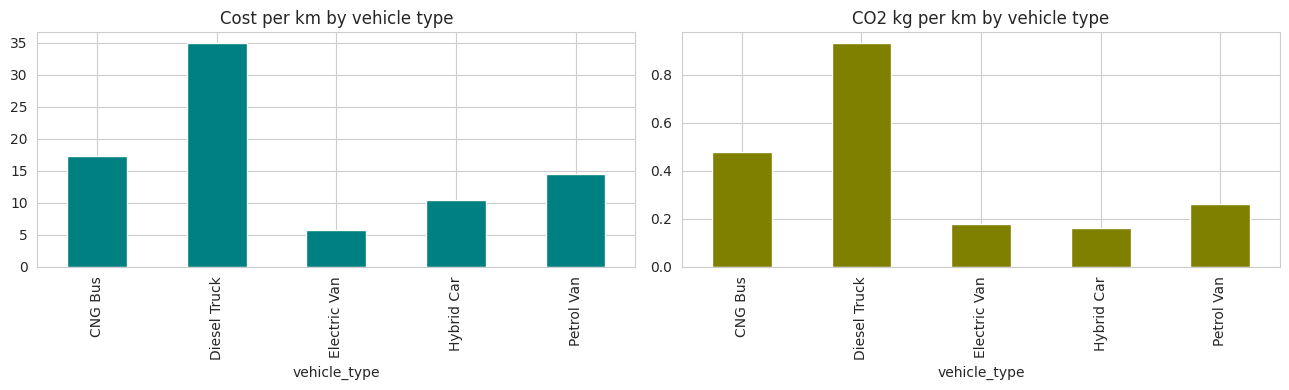

In [4]:
fleet["fuel_cost"] = fleet.apply(lambda r: r["fuel_used"] * fuel_price[r["fuel_type"]], axis=1)
fleet["co2_kg"] = fleet.apply(lambda r: r["fuel_used"] * co2_factor[r["fuel_type"]], axis=1)
fleet["use_per_100km"] = fleet["fuel_used"] / fleet["km"] * 100
fleet["total_cost"] = fleet["fuel_cost"] + fleet["maintenance_cost"]
fleet["idle_waste_cost"] = fleet["fuel_cost"] * fleet["idle_pct"] / 100 * 0.5

vehicle = fleet.groupby(["vehicle_id", "vehicle_type", "fuel_type"]).agg(
    age_years=("age_years", "first"), idle_pct=("idle_pct", "first"), driver_score=("driver_score", "first"),
    km=("km", "sum"), fuel_cost=("fuel_cost", "sum"), maintenance_cost=("maintenance_cost", "sum"),
    co2_kg=("co2_kg", "sum"), idle_waste_cost=("idle_waste_cost", "sum")).reset_index()
vehicle["cost_per_km"] = (vehicle["fuel_cost"] + vehicle["maintenance_cost"]) / vehicle["km"]
vehicle["co2_per_km"] = vehicle["co2_kg"] / vehicle["km"]

by_type = vehicle.groupby("vehicle_type").agg(vehicles=("vehicle_id", "count"), cost_per_km=("cost_per_km", "mean"),
                                                co2_per_km=("co2_per_km", "mean"), idle_waste=("idle_waste_cost", "sum")).round(2)
print(by_type)
print("\nFleet total CO2 (tonnes):", round(vehicle["co2_kg"].sum() / 1000, 1))
print("Fleet total fuel cost:", round(vehicle["fuel_cost"].sum()))
print("Idle waste cost:", round(vehicle["idle_waste_cost"].sum()))

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
by_type["cost_per_km"].plot(kind="bar", ax=ax[0], color="teal")
ax[0].set_title("Cost per km by vehicle type")
by_type["co2_per_km"].plot(kind="bar", ax=ax[1], color="olive")
ax[1].set_title("CO2 kg per km by vehicle type")
plt.tight_layout()
plt.show()

## Step 5: Find vehicles that cost more than their own type
Comparing a diesel truck with an electric van tells you nothing new (the type decides the cost). So each vehicle is compared with others of the **same type**. A z-score above 1.5 means clearly more expensive than its peers.

Vehicles costing much more than their own type: 7
   vehicle_id  vehicle_type  age_years  idle_pct  driver_score  cost_per_km  \
9        V010  Diesel Truck          9      25.6            40        40.96   
12       V013       CNG Bus         12      23.2            46        20.70   
54       V055  Diesel Truck          7      24.9            42        39.15   
73       V074    Petrol Van         11      26.4            52        17.01   
78       V079  Diesel Truck          9      16.8            55        38.75   
15       V016    Petrol Van         12      17.8            76        16.92   
20       V021  Diesel Truck         11      19.5            69        38.63   

    cost_z  
9     2.51  
12    1.87  
54    1.77  
73    1.65  
78    1.60  
15    1.60  
20    1.55  

Inside the diesel trucks, correlation with cost per km:
  idle %: 0.36
  driver score: -0.46
  age (years): 0.72
Worst 10% of diesel trucks cost 1.2 times more per km than the best 10%


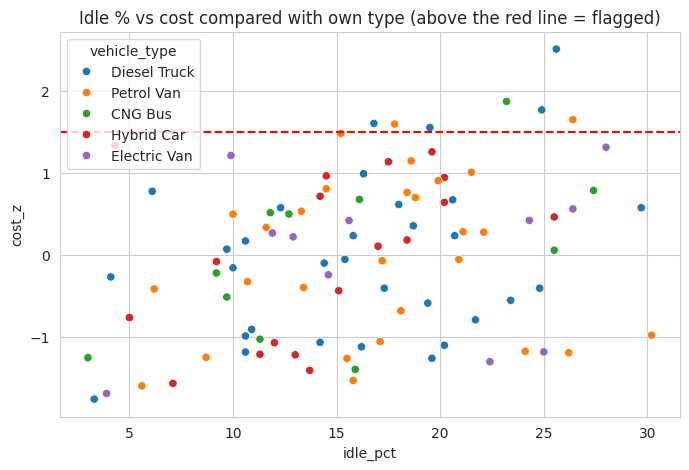

In [5]:
vehicle["cost_z"] = vehicle.groupby("vehicle_type")["cost_per_km"].transform(lambda x: (x - x.mean()) / (x.std() + 0.0001))
vehicle["anomaly"] = np.where(vehicle["cost_z"] >= 1.5, -1, 1)
odd = vehicle[vehicle["anomaly"] == -1].sort_values("cost_z", ascending=False)
print("Vehicles costing much more than their own type:", len(odd))
print(odd[["vehicle_id", "vehicle_type", "age_years", "idle_pct", "driver_score", "cost_per_km", "cost_z"]].round(2).head(10))

diesel = vehicle[vehicle["fuel_type"] == "Diesel"]
print("\nInside the diesel trucks, correlation with cost per km:")
print("  idle %:", round(diesel["idle_pct"].corr(diesel["cost_per_km"]), 2))
print("  driver score:", round(diesel["driver_score"].corr(diesel["cost_per_km"]), 2))
print("  age (years):", round(diesel["age_years"].corr(diesel["cost_per_km"]), 2))
diesel_corr = {"idle_pct": float(round(diesel["idle_pct"].corr(diesel["cost_per_km"]), 2)), "driver_score": float(round(diesel["driver_score"].corr(diesel["cost_per_km"]), 2)), "age_years": float(round(diesel["age_years"].corr(diesel["cost_per_km"]), 2))}
best10 = diesel["cost_per_km"].quantile(0.1)
worst10 = diesel["cost_per_km"].quantile(0.9)
print("Worst 10% of diesel trucks cost", round(worst10 / best10, 2), "times more per km than the best 10%")

plt.figure(figsize=(8, 5))
sns.scatterplot(data=vehicle, x="idle_pct", y="cost_z", hue="vehicle_type")
plt.axhline(1.5, color="red", linestyle="--")
plt.title("Idle % vs cost compared with own type (above the red line = flagged)")
plt.show()

## Step 6: What drives fuel use? (tested on vehicles the model has not seen)
Each vehicle appears 12 times (once per month) with the same age, idle % and driver score. If the same vehicle is in both the training and test data, the score looks better than it is. So 5-fold cross-validation is done **by vehicle**. With only 32 diesel vehicles, a small test set is very noisy, so cross-validation is more reliable than one split.

5-fold R2 by vehicle, Linear regression: 0.515 +/- 0.128
5-fold R2 by vehicle, Random forest: 0.318 +/- 0.173
The simple model wins, so it is used to rank the drivers (it is also easier to explain).
R2 of 0 means no better than guessing the average. Below 0.5, treat the driver ranking as a rough hint only.

Change in litres per 100 km for a 1 standard deviation increase in each factor:
age_years       1.28
idle_pct        1.01
km             -0.16
driver_score   -1.11
dtype: float64


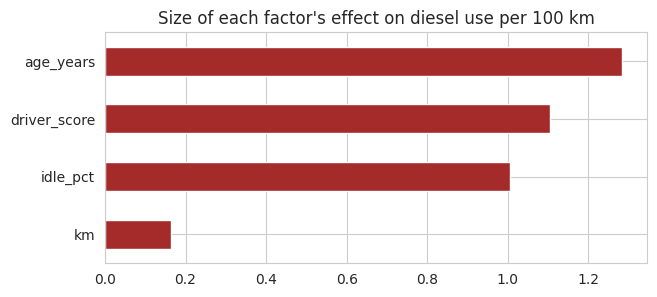

In [6]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

model_data = fleet[fleet["fuel_type"] == "Diesel"].reset_index(drop=True)
Xf = model_data[["age_years", "idle_pct", "driver_score", "km"]]
yf = model_data["use_per_100km"]
vehicle_groups = model_data["vehicle_id"]
cv_by_vehicle = GroupKFold(n_splits=5)

lin_pipe = make_pipeline(StandardScaler(), LinearRegression())
rf = RandomForestRegressor(n_estimators=150, max_depth=6, min_samples_leaf=5, random_state=42)
r2_lin = cross_val_score(lin_pipe, Xf, yf, cv=cv_by_vehicle, groups=vehicle_groups, scoring="r2")
r2_rf = cross_val_score(rf, Xf, yf, cv=cv_by_vehicle, groups=vehicle_groups, scoring="r2")
print("5-fold R2 by vehicle, Linear regression:", round(r2_lin.mean(), 3), "+/-", round(r2_lin.std(), 3))
print("5-fold R2 by vehicle, Random forest:", round(r2_rf.mean(), 3), "+/-", round(r2_rf.std(), 3))

if r2_lin.mean() >= r2_rf.mean():
    best_model_name = "Linear regression"
    best_r2 = float(r2_lin.mean())
    print("The simple model wins, so it is used to rank the drivers (it is also easier to explain).")
else:
    best_model_name = "Random forest"
    best_r2 = float(r2_rf.mean())
    print("The random forest scores higher, but drivers are still ranked with the linear model because it is easier to read.")
print("R2 of 0 means no better than guessing the average. Below 0.5, treat the driver ranking as a rough hint only.")

lin_pipe.fit(Xf, yf)
coefs = pd.Series(lin_pipe[-1].coef_, index=Xf.columns)
print("\nChange in litres per 100 km for a 1 standard deviation increase in each factor:")
print(coefs.round(2).sort_values(ascending=False))
imp = coefs.abs().sort_values()
imp.plot(kind="barh", figsize=(7, 3), color="brown")
plt.title("Size of each factor's effect on diesel use per 100 km")
plt.show()

## Step 7: Electric replacement scenario
Replace diesel trucks older than a chosen age with electric vans and see the yearly saving.

In [7]:
replace_age = 7
ev_extra_maintenance_saving = 0.25   # EV maintenance is assumed 25% cheaper

old_diesel = vehicle[(vehicle["fuel_type"] == "Diesel") & (vehicle["age_years"] >= replace_age)].copy()
ev_use_per_km = base_use_per_100km["Electric"] / 100
old_diesel["ev_energy_cost"] = old_diesel["km"] * ev_use_per_km * fuel_price["Electric"]
old_diesel["ev_co2"] = old_diesel["km"] * ev_use_per_km * co2_factor["Electric"]
old_diesel["ev_maint"] = old_diesel["maintenance_cost"] * (1 - ev_extra_maintenance_saving)
old_diesel["cost_saving"] = (old_diesel["fuel_cost"] + old_diesel["maintenance_cost"]) - (old_diesel["ev_energy_cost"] + old_diesel["ev_maint"])
old_diesel["co2_saving_kg"] = old_diesel["co2_kg"] - old_diesel["ev_co2"]

print("Vehicles to replace:", len(old_diesel))
print("Yearly cost saving:", round(old_diesel["cost_saving"].sum()))
print("Yearly CO2 saving (tonnes):", round(old_diesel["co2_saving_kg"].sum() / 1000, 1))
print("Share of fleet CO2 removed:", round(old_diesel["co2_saving_kg"].sum() / vehicle["co2_kg"].sum() * 100, 1), "%")

ev_cost_each = 2500000
invest = ev_cost_each * len(old_diesel)
if old_diesel["cost_saving"].sum() > 0:
    print("Simple payback (years):", round(invest / old_diesel["cost_saving"].sum(), 1), "(assuming", ev_cost_each, "per EV)")

ages = []
for a in range(3, 12):
    sub = vehicle[(vehicle["fuel_type"] == "Diesel") & (vehicle["age_years"] >= a)]
    ages.append((a, len(sub)))
print("\nDiesel vehicles by minimum age:", ages)

print("\nPayback if the electric vehicle costs more than assumed (same yearly saving):")
total_saving = old_diesel["cost_saving"].sum()
for price in [2500000, 4000000, 6000000, 8000000]:
    if total_saving > 0:
        print("  EV price", price, "each ->", round(price * len(old_diesel) / total_saving, 1), "years")

print("\nYearly saving if electricity costs more than assumed:")
for elec_price in [9, 12, 15]:
    new_energy = old_diesel["km"] * ev_use_per_km * elec_price
    saving = ((old_diesel["fuel_cost"] + old_diesel["maintenance_cost"]) - (new_energy + old_diesel["ev_maint"])).sum()
    print("  electricity", elec_price, "per kWh ->", round(saving))
print("\nWarning: this assumes an electric van can do a diesel truck's job and that the numbers at the top are right. Treat it as a what-if, not a business case.")

Vehicles to replace: 15
Yearly cost saving: 21077848
Yearly CO2 saving (tonnes): 537.1
Share of fleet CO2 removed: 26.1 %
Simple payback (years): 1.8 (assuming 2500000 per EV)

Diesel vehicles by minimum age: [(3, 23), (4, 22), (5, 21), (6, 20), (7, 15), (8, 12), (9, 9), (10, 6), (11, 4)]

Payback if the electric vehicle costs more than assumed (same yearly saving):
  EV price 2500000 each -> 1.8 years
  EV price 4000000 each -> 2.8 years
  EV price 6000000 each -> 4.3 years
  EV price 8000000 each -> 5.7 years

Yearly saving if electricity costs more than assumed:
  electricity 9 per kWh -> 21077848
  electricity 12 per kWh -> 20681396
  electricity 15 per kWh -> 20284944



## Step 8: AI recommendations (Groq)
All scenario numbers are calculated here in code. The AI only explains them, it does not calculate.

In [8]:
fleet["idle_co2_kg"] = fleet["co2_kg"] * fleet["idle_pct"] / 100 * 0.5
idle_cut = 0.5
idle_cost_saving = vehicle["idle_waste_cost"].sum() * idle_cut
idle_co2_saving_t = fleet["idle_co2_kg"].sum() * idle_cut / 1000

odd_excess_cost = (odd["cost_per_km"] - vehicle.groupby("vehicle_type")["cost_per_km"].transform("median").loc[odd.index]) * odd["km"]
fix_odd_saving = odd_excess_cost.clip(lower=0).sum()

worst_types = by_type.sort_values("co2_per_km", ascending=False)
text = f"""
Fleet size: {vehicle['vehicle_id'].nunique()} vehicles. No currency is given, do not add a currency symbol.
Total CO2: {vehicle['co2_kg'].sum()/1000:.1f} tonnes. Total fuel cost: {vehicle['fuel_cost'].sum():.0f}.
Idle waste cost (assumed formula): {vehicle['idle_waste_cost'].sum():.0f}
Highest CO2 per km vehicle type: {worst_types.index[0]} ({worst_types.iloc[0]['co2_per_km']:.2f} kg/km)
Scenario 1, replace diesel vehicles aged {replace_age}+ with electric (assumes an electric vehicle can do the same work): {len(old_diesel)} vehicles, saving {old_diesel['cost_saving'].sum():.0f} per year, CO2 cut {old_diesel['co2_saving_kg'].sum()/1000:.1f} tonnes
Scenario 2, cut idling by half: saving {idle_cost_saving:.0f} per year, CO2 cut {idle_co2_saving_t:.1f} tonnes
Scenario 3, bring the {len(odd)} vehicles that cost much more per km than other vehicles of their own type down to their type's median cost per km (through maintenance, driver coaching or replacement): saving {fix_odd_saving:.0f} per year
Inside diesel trucks the worst 10% cost {worst10 / best10:.2f} times more per km than the best 10%
Correlation with cost per km inside diesel trucks: {diesel_corr}
Fuel-use model ({best_model_name}, 5-fold by vehicle): R2 {best_r2:.2f}. This is a weak model, so do not base advice on its ranking.
"""
reco = ask_llm("Give a fleet manager 5 clear recommendations using only the numbers and scenarios below. Do NOT calculate new numbers, do NOT add currency symbols, do NOT call scenario 3 re-pricing, and say once that the data is made up and the scenarios depend on assumptions. Where the fuel-use model is weak (R2 under 0.5), base advice on the correlations instead.\n" + text,
               system="You are a fleet sustainability analyst. Do not invent numbers.")
print(reco)

**Important note:** The figures below are made‑up and the scenarios depend on assumptions.

1. **Electrify the oldest diesel trucks** – Replace the 15 diesel vehicles that are 7 years or older with electric equivalents. This action is projected to save **21,077,848** per year and cut CO₂ emissions by **537.1 tonnes**.

2. **Halve idling time fleet‑wide** – Reducing idling by 50 % is expected to save **2,931,857** per year and lower CO₂ output by **84.5 tonnes**.

3. **Align high‑cost vehicles to median cost per km** – For the 7 vehicles that currently cost far more per kilometre than their peers, bring their cost down to the type’s median (through maintenance, driver coaching or replacement). This measure would save **1,106,999** per year.

4. **Target vehicle age to improve cost efficiency** – The correlation between cost per kilometre and vehicle age in diesel trucks is **0.72**. Prioritising younger diesel trucks for high‑usage routes or retiring the oldest units can reduce per‑kilo

## Step 9: Key insights and export

In [9]:
print("KEY INSIGHTS (calculated from this run)")
print("1. Vehicle types differ a lot (", worst_types.index[0], "has the highest CO2 per km), but that is mostly set by the assumed fuel and CO2 numbers at the top of the notebook")
print("2. The more useful finding is the spread inside one type: worst 10% of diesel trucks cost", round(worst10 / best10, 2), "times more per km than the best 10%")
print("3. Idle waste is", round(vehicle["idle_waste_cost"].sum() / vehicle["fuel_cost"].sum() * 100, 1), "% of fuel cost; halving idling saves about", round(idle_cost_saving), "per year")
print("4. Replacing", len(old_diesel), "old diesel vehicles removes", round(old_diesel["co2_saving_kg"].sum() / 1000, 1), "tonnes CO2, but the payback depends a lot on EV price (see the table above)")
print("5. Vehicles costing much more than their own type:", len(odd))
print("6. Fuel-use model (" + best_model_name + ") R2 by vehicle:", round(best_r2, 2), "- weak, so the driver ranking is only a hint. Strongest link to cost per km among diesel trucks:", diesel_corr)
print("7. All data here is made up unless you upload fleet.csv")

vehicle.to_csv("fleetfulcrum_vehicles.csv", index=False)
fleet.to_csv("fleetfulcrum_monthly.csv", index=False)
print("\nSaved fleetfulcrum_vehicles.csv and fleetfulcrum_monthly.csv")

KEY INSIGHTS (calculated from this run)
1. Vehicle types differ a lot ( Diesel Truck has the highest CO2 per km), but that is mostly set by the assumed fuel and CO2 numbers at the top of the notebook
2. The more useful finding is the spread inside one type: worst 10% of diesel trucks cost 1.2 times more per km than the best 10%
3. Idle waste is 8.2 % of fuel cost; halving idling saves about 2931857 per year
4. Replacing 15 old diesel vehicles removes 537.1 tonnes CO2, but the payback depends a lot on EV price (see the table above)
5. Vehicles costing much more than their own type: 7
6. Fuel-use model (Linear regression) R2 by vehicle: 0.51 - weak, so the driver ranking is only a hint. Strongest link to cost per km among diesel trucks: {'idle_pct': 0.36, 'driver_score': -0.46, 'age_years': 0.72}
7. All data here is made up unless you upload fleet.csv

Saved fleetfulcrum_vehicles.csv and fleetfulcrum_monthly.csv



---
Built by **Akshat Kesharwani** | [GitHub](https://github.com/akshatkesharwani-info) | [Portfolio](https://akshatkesharwani-info.github.io/)